# SPRINT S8.01

Visualizaciones en Python

NIVEL 01:

Realiza la conexión en Python con MySQL Workbench para cargar toda la información que tienes en las tablas.
Harás una visualización para cada ejercicio. Comenta qué te llama la atención al graficar esa variable, justifica la elección del gráfico e interpreta los resultados en función de tus datos.

Explicación del código utilizado: se establece una conexión entre la db de MySQL (db_sp04_transaction) y extrae los datos de 5 tablas específicas, convirtiéndolas en un DataFrame de pandas. Inicialmente, se importan las librerías (pandas y mysqlconector) y luego se especifican los parámetros de conexión entre Python y MySQL (localhost, database, user and password). Luego, si definen en una lista, las tablas que serán cargadas.

El núcleo del script es un bucle que recorre cada nombre de tabla y ejecuta una ‘query’ de SQL (‘SELECT * FROM {nombre_tabla}’), que será leído por el comando pd.read_sql, guardando el resultado en un Dataframe. Se ha utilizado de esta forma, que como visto en la revisión por peers, es una forma más escalable, visto que no guardamos las tablas en un diccionario, lo que podría ser factible en este ejercicio, con pocas tablas, pero si es un database con muchas tablas, dejaría el trabajo más complicado. Así este abordaje es más eficiente. Después de cargar las tablas seleccionadas, se imprime un mensaje, comunicando que fueron cargadas con éxito.

Por último, se ha creado el cursor, un objeto que permite ejecutar comandos SQL dentro del script, mejorando y facilitando la organización del código. Al final, si cierra la conexión y el cursor con el método. close().

In [43]:
import pandas as pd
import mysql.connector

# Configuración de la conexión a la base de datos
host = 'localhost'
database = 'db_sp04_transaction'
user = 'root'
password = '1984'

# Establecer la conexión
conexao = mysql.connector.connect(
    host=host,
    database=database,
    user=user,
    password=password
)

cursor = conexao.cursor()

tablas = ['db_company', 'db_products', 'db_transaction_product', 'db_transactions', 'db_user']

for nombre_tabla in tablas:
    query = f'SELECT * FROM {nombre_tabla}'
    df = f'df_{nombre_tabla}'
    globals()[df] = pd.read_sql(query, con=conexao)
    print(f'{nombre_tabla} cargada con exito!')

# Cerrar la conexión
cursor.close()
conexao.close()

# Cursor.execute("DROP TABLE IF EXISTS mytable")

db_company cargada con exito!
db_products cargada con exito!
db_transaction_product cargada con exito!
db_transactions cargada con exito!
db_user cargada con exito!


C:\Users\Usuario\AppData\Local\Temp\ipykernel_16696\880247519.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  globals()[df] = pd.read_sql(query, con=conexao)


Verificando se las tablas fueron importadas correctamente:

In [44]:
df_db_company.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_id    100 non-null    object
 1   company_name  100 non-null    object
 2   phone         100 non-null    object
 3   email         100 non-null    object
 4   country       100 non-null    object
 5   website       100 non-null    object
dtypes: object(6)
memory usage: 4.8+ KB


In [45]:
df_db_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            100 non-null    object 
 1   product_name  100 non-null    object 
 2   price         100 non-null    object 
 3   colour        100 non-null    object 
 4   weight        100 non-null    float64
 5   warehouse_id  100 non-null    object 
dtypes: float64(1), object(5)
memory usage: 4.8+ KB


Si hace la limpieza de la columna price y cambiar el tipo de dato, de string a float.

In [46]:
# limpiar la columna price y cambiar tipo de dato:
df_db_products['price'] = df_db_products['price'].str.replace(r'\$', '', regex = True).astype(float)
df_db_products.head()

,id,product_name,price,colour,weight,warehouse_id
0,1,Direwolf Stannis,161.11,#7c7c7c,1.0,WH-4
1,10,Karstark Dorne,119.52,#f4f4f4,2.4,WH--5
2,100,south duel,40.43,#6d6d6d,3.0,WH--95
3,11,Karstark Dorne,49.70,#141414,2.7,WH--6
4,12,duel Direwolf,181.60,#a8a8a8,2.1,WH--7


In [47]:
df_db_transaction_product.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1457 entries, 0 to 1456
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   transaction_id  1457 non-null   object
 1   product_id      1457 non-null   object
dtypes: object(2)
memory usage: 22.9+ KB


In [48]:
df_db_transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 587 entries, 0 to 586
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id           587 non-null    object        
 1   card_id      587 non-null    object        
 2   business_id  587 non-null    object        
 3   timestamp    587 non-null    datetime64[ns]
 4   amount       587 non-null    float64       
 5   declined     587 non-null    int64         
 6   product_ids  587 non-null    object        
 7   user_id      587 non-null    int64         
 8   lat          587 non-null    float64       
 9   longitude    587 non-null    float64       
dtypes: datetime64[ns](1), float64(3), int64(2), object(4)
memory usage: 46.0+ KB


In [49]:
df_db_user.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           275 non-null    int64 
 1   name         275 non-null    object
 2   surname      275 non-null    object
 3   phone        275 non-null    object
 4   email        275 non-null    object
 5   birth_date   275 non-null    object
 6   country      275 non-null    object
 7   city         275 non-null    object
 8   postal_code  275 non-null    object
 9   address      275 non-null    object
dtypes: int64(1), object(9)
memory usage: 21.6+ KB


Antes de seguir con los ejercicios, importamos las librerías que vamos a utilizar:

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

* Nivel 01: Ejercicio 01: Una variable numérica.

Explicación de la selección del gráfico y código:

Para enseñar la distribución de importes de las transacciones, se ha elegido utilizar un histograma, utilizando el seaborn, presentando el contaje de veces de los importes realizados, en sus rangos de valores totales. Este gráfico, ayudara a visualizar el patrón de los rangos de valores y como las transacciones están distribuidas, si en rangos más altos, medios o más bajos.
El grafico presenta barras en 20 (bins) rangos de importes (eje X) y la frecuencia de ocurrencia de estos (eje Y). se ha añadido una curva superpuesta, para verificar la densidad de ocurrencias, KDE (Kernel Density Estimate). Por fin, personalizamos el grafico, añadiendo, título al grafico y a sus ejes, así como definimos un color para seguir el patrón de presentación del sprint 06.

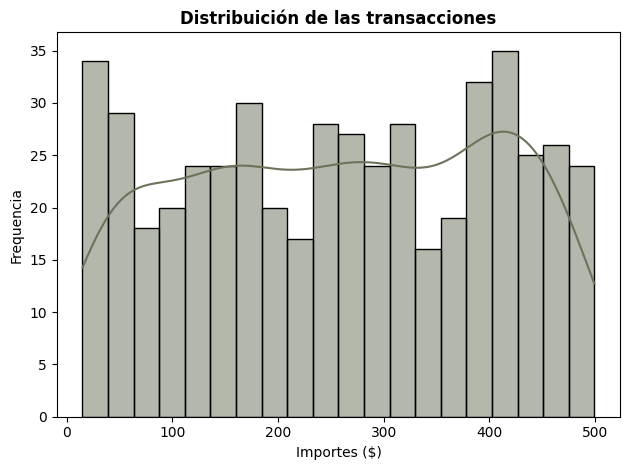

In [51]:
# Filtro por transacciones realizadas:
trans_realizadas = df_db_transactions[df_db_transactions['declined'] == False]

# Visualización de la distribución de las transacciones:
sns.histplot(trans_realizadas['amount'], kde=True, bins=20, color='#6B735A')
plt.title('Distribuición de las transacciones', fontsize=12, fontweight='bold')
plt.xlabel('Importes ($)', fontsize=10)
plt.ylabel('Frequencia', fontsize=10)
plt.tight_layout()
plt.show()

Análisis del resultado: refleja claramente que la mayoría de las transacciones se concentran entre los importes de ($) 200 a 400, siendo los más frecuentes y corroborando con la curva KDE, que demuestra la moda en estos valores, como la tendencia. Transacciones con importes bajos o muy altos son poco comunes y podrían ser verificados como outliers.

* NIVEL 01: Ej02: Dos variables numéricas.

Explicación de la selección del gráfico y código:

Fue seleccionado el grafico de dispersión (scatter plot) para evaluar la relación entre peso y precio de los productos, utilizando solo las dos variables numéricas de la tabla productos. Este grafico muestra puntos individuales de datos en un plano cartesiano, donde cada punto representa un objeto de un conjunto de datos, ayuda a identificar si hay algún patrón o relación entre el peso y coste de los productos.
Cada punto en el gráfico representa un producto, donde los precios en dólares ($), están presentados en el eje X y el peso en Kg, en el eje Y. Se utiliza las librerías seaborn, para creación de la gráfica y la librería matplotlib para personalizar e imprimir el grafico. Personalizamos el título y los nombres de los ejes.

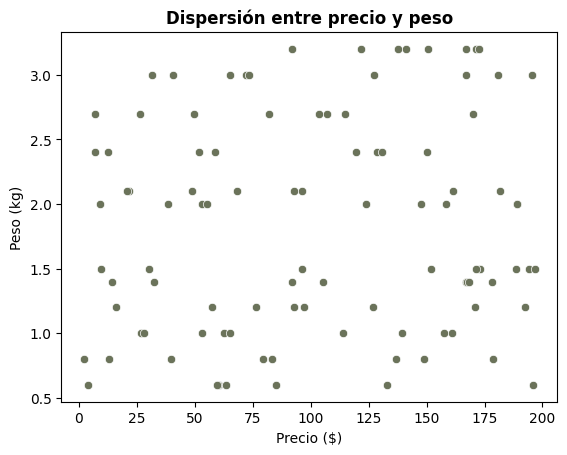

In [52]:
# Disperción entre precio y peso
sns.scatterplot(data=df_db_products, x='price', y='weight', color='#6B735A')
plt.title('Dispersión entre precio y peso', fontsize=12, fontweight='bold')
plt.xlabel('Precio ($)', fontsize=10)
plt.ylabel('Peso (kg)', fontsize=10)
plt.show()

Analisis de los resultados: existe una correlación blanda entre precio y peso, sugiriendo que los productos más caros, tienden a tener precios mayores, pero la relación entre ellos no es linear, demostrado que solo estas dos variables no son suficiente para determinar el precio de los productos. A medida que el precio aumenta, el peso también tiende a aumentar, pero no es de forma uniforme. Luego, no se perciben puntos muy dislocados o fuera de rango (outliers).

* NIVEL 01: Ej03: Una variable categórica.

Explicación de la selección del gráfico y código:

Para este ejercicio, fue utilizado el grafico de barras horizontales, para identificar el número de usuarios por países. En este caso, se ha utilizado la librería matplotlib, mediante el llamado de ‘barh’, que representa barras horizontales. Para tener el dato, se ha utilizado el método.values_counts() para hacer el contaje de los usuarios por país y para finalizar se ha personalizado los colores de las barras, con la variable colores, identificando el número RGB de cada color. La función tigh_layout(), garantiza que los elementos del grafico se ajusten de forma adecuada, evitando que se sobrepongan.

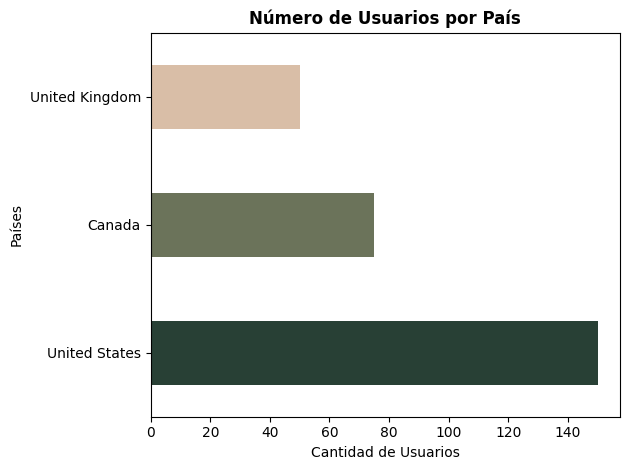

In [53]:
#Colores para las barras
colors = ['#284035', '#6B735A', '#D9BEA7']

# Cálculo del número de usuarios por país y llamada del gráfico de barras horizontal
df_db_user['country'].value_counts().plot(kind='barh', color=colors)

plt.title('Número de Usuarios por País', fontsize=12, fontweight='bold')
plt.xlabel('Cantidad de Usuarios', fontsize=10)
plt.ylabel('Países', fontsize=10)
plt.tight_layout()
plt.show()

Análisis de los resultados: la grafica muestra el numero de usuarios por país, evidenciando que los Estados Unidos tiene 150, siendo el mayor mercado.

* NIVEL 01: Ej04: Una variable categórica y una numérica.

Explicación de la selección del gráfico y código:

En este ejercicio, utilizamos la suma de lo valores de las transacciones realizadas de las empresas, para presentar de forma gráfica, en barras horizontales, los importes totales de cada país. Este ayudara a visualizar cuales son los países que contribuyen más para el negocio.
Inicialmente se hace un merge (join) entre las tablas de empresas y transacciones, luego se filtra solo las transacciones que fueron exitosas y por último, se agrupa entre países y se calcula la suma del amount de las transacciones exitosas de cada país. Estés resultados son almacenados en una nueva tabla (total_paises) y se crea el nombre de la nueva columna como Total Ventas para llamar en el gráfico. Y por último, se ordena los resultados en orden creciente de ventas para mejor visualización.

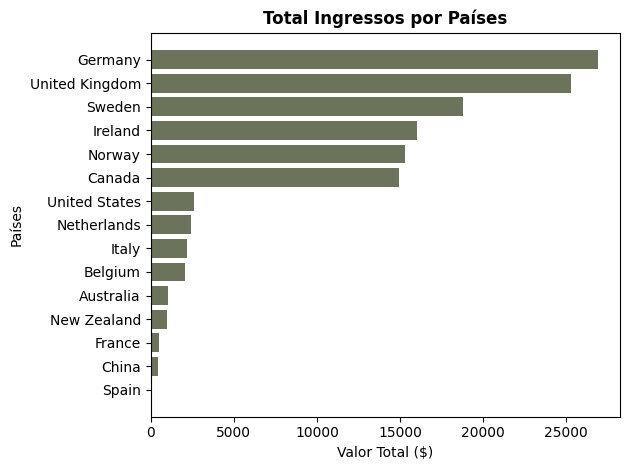

In [38]:
# Gráfico de barras del total de ingresso de las transacciones por país
data = df_db_transactions.merge(df_db_company, left_on='business_id', right_on='company_id', how='inner')
trans_realizadas = data[data['declined'] == False]
total_paises = trans_realizadas.groupby('country')['amount'].sum().reset_index(name='Total Ventas')
total_paises = total_paises.sort_values(by='Total Ventas', ascending=True)

plt.barh(total_paises['country'], total_paises['Total Ventas'], color='#6B735A')
plt.title('Total Ingressos por Países', fontsize=12, fontweight='bold')
plt.xlabel('Valor Total ($)', fontsize=10)
plt.ylabel('Países', fontsize=10)
plt.tight_layout()
plt.show()

Análisis de los resultados: permite identificar fácilmente los mercados que son más lucrativos para el negocio, ayudando en la toma de decisiones. Luego, queda evidente que Alemania tiene mucho peso, seguido de Reino Unido, Suecia, Irlanda, Noruega e Canadá. Los demás mercados, tienen colaboración tímida o casi nula como China y España. Esta visualización podría servir para el sector financiero definir rumbos de incentivar los mercados ‘tímidos’ o potencializar los que están en ascenso. 

* NIVEL 01: Ej05: Dos variables categóricas.

Explicación de la selección del gráfico y código:
Análisis de los estatus de las transacciones por países, con grafico de barras verticales apilado (stacked=True). Este grafico presenta la cantidad de transacciones aceptadas y rechazadas de cada país. Esto ayudará identificar los patrones de éxito entre los diferentes mercados y tomas decisiones basadas en la eficacia de cada país.
Para evitar de hacer un merge, en este caso se crea una variable (ct) para criar una tabla cruzada (crosstab), como una tabla resumo, que cuenta las transacciones aceptadas y las rechazadas, agrupadas por países. Esta función, reorganiza los datos combinados en un formato resumido, criando una tabla ‘pivot’ que presenta los resultados entre países y transacciones.

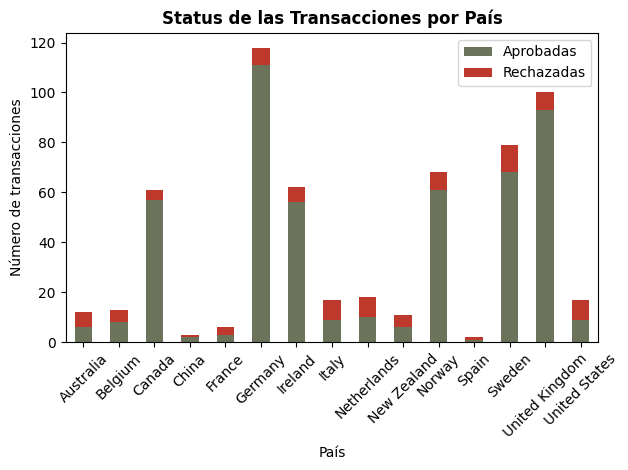

In [39]:
# Transacciones aceptadas x rechazadas por país:
ct = pd.crosstab(data['country'], data['declined'])
ct.plot(kind='bar', stacked=True, 
        color=['#6B735A', '#BF382C'])
       
plt.title('Status de las Transacciones por País', fontsize=12, fontweight='bold')
plt.xlabel('País', fontsize=10)
plt.ylabel('Número de transacciones', fontsize=10)
plt.legend(['Aprobadas', 'Rechazadas'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Análisis de los resultados: esta gráfica, permite visualizar de forma clara el desempeño de las transacciones de cada país, permitiendo detectar tendencias o problemas entre la relación de éxito o no de las transacciones.

* NIVEL 01: Ej06: Tres variables.

Explicación de la selección del gráfico y código:
Se selecciona el gráfico de tipo dispersión ("scatter") para visualizar la relación entre las variables "x", "y" y "z". Mestra la relación entre tres variables diferentes de un conjunto de datos. El objetivo es ayudar a analizar y comprender visualmente cómo se relacionan entre sí las ventas del producto, los nombres de los productos y sus precios. Cada producto está representado por un punto de color. La posición horizontal (eje x) muestra el monto total de ventas en dólares, la posición vertical (eje y) muestra el nombre del producto, y el color de cada punto representa el precio del producto. 

In [ ]:
#Conexion entre las tablas y creación del dataframe puente.
conexion_transaciones_puente = df_db_transactions.merge(df_db_transaction_product, left_on='id', right_on='transaction_id', how='inner')

prod_with_names = conexion_transaciones_puente.merge(df_db_products, left_on='product_id', right_on='id', how='inner')

ventas_realizadas = prod_with_names[prod_with_names['declined'] == False]
suma_prod_sales = ventas_realizadas.groupby(['product_id', 'price','product_name','weight'])['amount'].sum().reset_index()
suma_prod_sales.columns = ['product_id', 'price','product_name','weight','product_sales']
suma_prod_sales.head()

,product_id,price,product_name,weight,product_sales
0,1,161.11,Direwolf Stannis,1.0,12733.83
1,11,49.70,Karstark Dorne,2.7,10096.03
2,13,139.59,palpatine chewbacca,1.0,12961.85
3,17,91.89,skywalker ewok sith,3.2,14293.76
4,19,60.33,dooku solo,0.6,11542.77


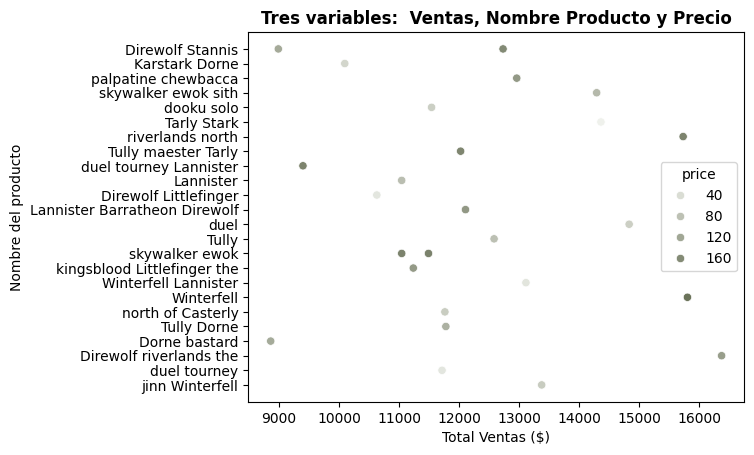

In [ ]:
# Gráfica de dispersión entre las 3 variables: ventas, nombre del producto y precio.
sns.scatterplot(data=suma_prod_sales, x='product_sales', y='product_name', hue='price', palette=sns.light_palette("#6B735A", as_cmap=True))
plt.title('Tres variables:  Ventas, Nombre Producto y Precio', fontsize=12, fontweight='bold')
plt.xlabel('Total Ventas ($)', fontsize=10)
plt.ylabel('Nombre del producto', fontsize=10)
plt.show()

Anális de los resultados: La gráfica muestra cómo se relacionan las ventas, los nombres de los productos y sus precios. Aunque no hay una correlación directa entre el precio y las ventas, se identifican patrones útiles para la toma de decisiones. Las ventas totales varían desde cerca de 9.000 hasta más de 16.000, con los productos más vendidos ubicados en el lado derecho del gráfico. Productos como "Direwolf Stannis" tienen bajas ventas y precios altos, mientras que otros como "Dorne bastard" registran buenas ventas a pesar de su bajo costo. Esto refleja una clara segmentación del mercado: algunos clientes prefieren productos premium y otros buscan opciones económicas. Se destacan tres oportunidades clave: aprovechar los productos con altas ventas y precios altos para reforzar su imagen de valor; mejorar la estrategia de precios o promoción en productos caros pero poco vendidos; y utilizar los productos baratos pero exitosos como estrellas para atraer a consumidores sensibles al precio.

* NIVEL 01: Ej07 Graficar un Pairplot.

Un pairplot es un gráfico que muestra relaciones entre todas las variables numéricas de un conjunto de datos. Es como una tabla de doble entrada: cada fila y columna representa una variable. En la diagonal se ve la distribución de cada variable, y fuera de la diagonal, los gráficos de dispersión muestran cómo se relacionan entre sí.

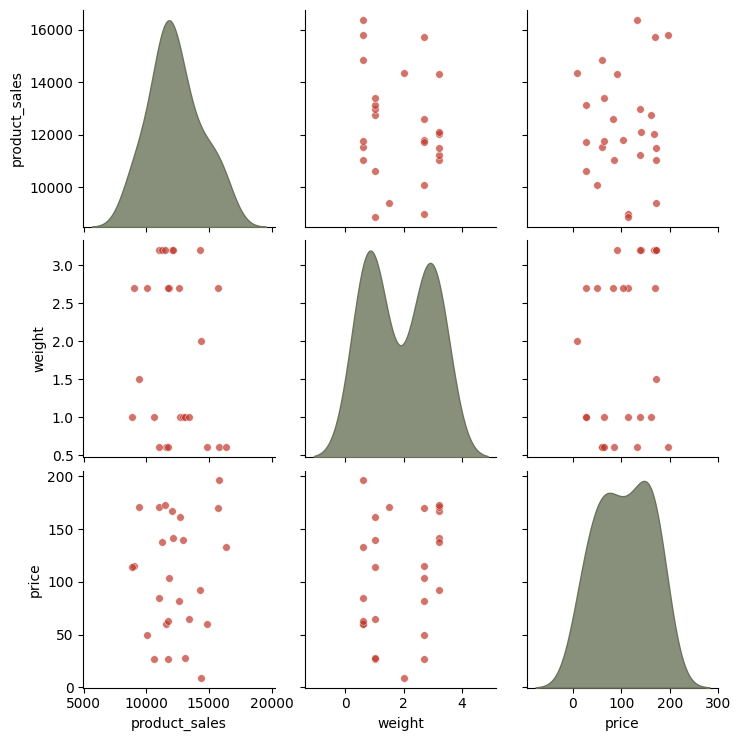

In [42]:
columns = ['product_sales','weight', 'price']
g = sns.pairplot(suma_prod_sales[columns], 
                 diag_kind='kde',
                 plot_kws={'color': '#BF382C', 'alpha': 0.7, 's': 30},
                 diag_kws={'color': '#6B735A', 'alpha': 0.8})  

Análisis de los resultados: el pairplot muestra cómo se distribuyen los datos de cada variable (en la diagonal) y cómo se relacionan entre sí (fuera de la diagonal), como si fuera una tabla de doble entrada. En este caso, vemos que:

Distribuciones: las ventas se concentran cerca de 10.000, el peso tiene dos grupos (alrededor de 1 y de 3), y el precio ronda los 100.
Relaciones: no hay relación clara entre ventas y peso o precio; sin embargo, productos más pesados tienden a ser más caros.

# NIVEL 02

* NIVEL 02: Ej01: Correlación de todas las variables numéricas.

Explicación de la selección del gráfico y código:
El método .corr() de pandas calcula la matriz de correlación entre todas las variables numéricas del DataFrame suma_prod_sales. Por defecto, usa el coeficiente de Pearson, que mide la correlación lineal entre dos variables. Este varía entre -1 y 1 de la siguiente forma: 1 es la correlación positiva perfecta, 0 es sin correlación lineal y -1: correlación negativa perfecta. Solo detecta relaciones lineales (no sirve para detectar relaciones curvas, por ejemplo).

In [ ]:
# Cálculo  de la suma de ventas por producto.
suma_prod_sales = ventas_realizadas.groupby(['price','weight'])['amount'].sum().reset_index()
suma_prod_sales.columns = ['price','weight','product_sales']
suma_prod_sales.head()

,price,weight,product_sales
0,9.24,2.0,14365.10
1,26.51,2.7,11717.10
2,26.66,1.0,10630.10
3,28.01,1.0,13115.05
4,49.70,2.7,10096.03


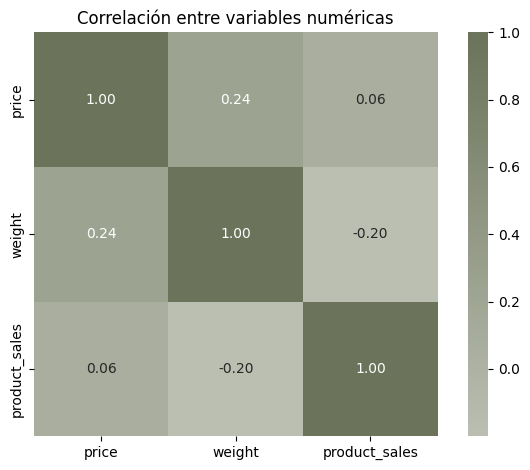

In [ ]:
# Utilizamos el .corr () para calcular la correlación entre las variables numéricas.
correlacao = suma_prod_sales.corr()
sns.heatmap(correlacao, 
            annot=True,           
            cmap=sns.light_palette("#6B735A", as_cmap=True),      
            center=0,             
            square=True,          
            fmt='.2f')           

plt.title('Correlación entre variables numéricas')
plt.tight_layout()
plt.show()

Análisis de los resultados: Este análisis muestra que no hay relaciones fuertes entre las variables. El pairplot y el heatmap se complementan: el primero permite ver la forma de la relación visualmente, y el segundo la cuantifica. En este caso, se observa que: price x weight tiene una correlación positiva débil (0.24), o sea, productos más pesados tienden a ser más caros, aunque no de forma tan frecuente o lineal. El product_sales x weight tiene correlación negativa débil (-0.20), los productos más pesados venden ligeramente menos. Y al final el product_sales x price tiene correlación casi nula (0.06), en este sentido el precio no parece afectar directamente las ventas.

* NIVEL 02: Ej02: Implementa un Jointplot.

Explicación de la selección del gráfico y código: El método jointplot, crea una grafica combina que muestra un gráfico de dispersión (scatter plot) en el centro, comparando dos variables (aprobadas y rechazadas) y distribuciones en los ejes superiores y derecho, muestra de la densidad. 

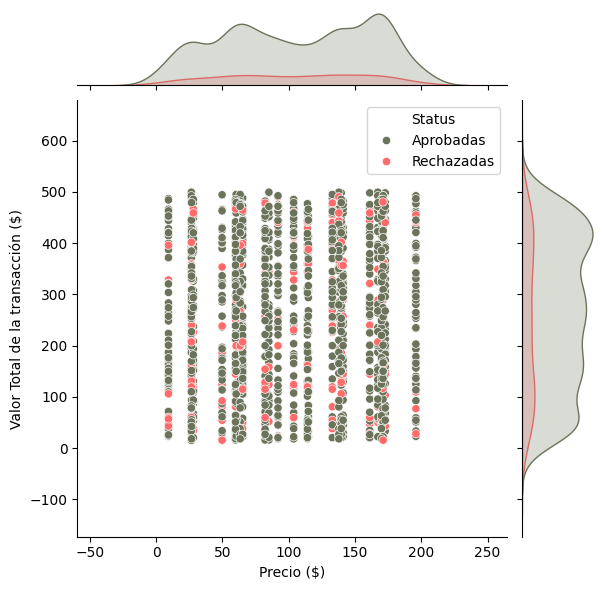

In [19]:
merge_transacciones = pd.merge(df_db_transactions, df_db_transaction_product, left_on='id', right_on='transaction_id')
dataframe_final = pd.merge(merge_transacciones, df_db_products, left_on='product_id', right_on='id')

# Jointplot con colores personalizados:
g = sns.jointplot(data=dataframe_final, x='price', y='amount', hue='declined',
                  palette={False: '#6B735A', True: '#FF6B6B'}) 

# Personalizar labels:
g.set_axis_labels('Precio ($)', 'Valor Total de la transacción ($)', fontsize=10)

# Personalizar legenda
legend = g.ax_joint.legend()
legend.set_title('Status')
labels = ['Aprobadas', 'Rechazadas']
for i, text in enumerate(legend.get_texts()):
    text.set_text(labels[i])

plt.show()

Análisis de los resultados: el jointplot permite analizar como varían juntas dos variables (precio y monto total), y como se distribuyen por separado, así que se evidencia que las transacciones rechazadas no parecen tener un patrón que les pueda diferenciar de las aprobadas. Pero, mirando la gráfica, si puede ver que hay una pequeña concentración de transacciones rechazadas en los valores más bajos ($50 y $150).

# NIVEL 03

* NIVEL 03: Ej01: Implementa un Violinplot combinado con otro tipo de gráfico.

Explicación de la selección del gráfico y código: en este caso se ha elegido un Violin Plot (gráfico de violín) y Strip Plot (gráfico de puntos individuales).

In [54]:
# Filtrar los datos de los usuarios que no tienen transacciones rechazadas.
data_usuarios = df_db_transactions.merge(df_db_user, left_on='user_id', right_on='id', how='inner')
data_usuarios

usuarios_resumo = data_usuarios[data_usuarios['declined'] == False].groupby(['user_id', 'country']).agg({'amount': ['sum', 'count']}).reset_index()
usuarios_resumo

usuarios_resumo.columns = ['user_id', 'country', 'total_compras', 'num_transacoes']
usuarios_resumo

,user_id,country,total_compras,num_transacoes
0,60,United States,156.23,1
1,61,United States,460.82,1
2,62,United States,133.39,1
3,63,United States,82.43,1
4,64,United States,471.47,1
...,...,...,...,...
211,271,Canada,787.52,2
212,272,Canada,9681.60,38
213,273,Canada,529.36,2
214,274,Canada,637.76,2


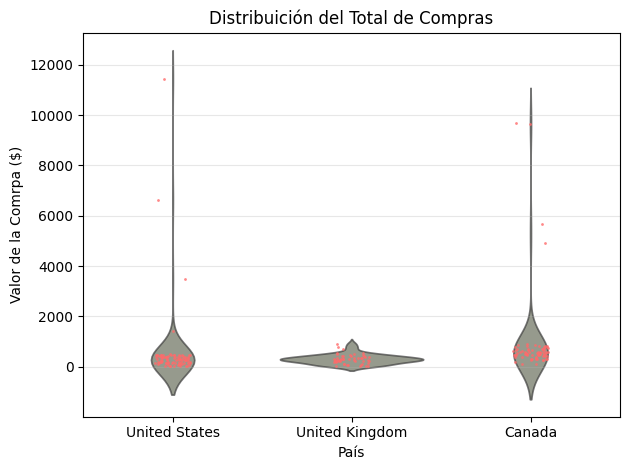

In [21]:
sns.violinplot(data=usuarios_resumo, x='country', y='total_compras', 
               inner=None, color='#6B735A', alpha=0.7)

# Stripplot sobreposto (pontos individuais)
sns.stripplot(data=usuarios_resumo, x='country', y='total_compras', 
              color='#FF6B6B', alpha=0.8, size=2)

plt.title('Distribuición del Total de Compras', fontsize=12)
plt.xlabel('País', fontsize=10)
plt.ylabel('Valor de la Comrpa ($)', fontsize=10)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Análisis del gráfico: el gráfico de violín muestra la distribución de los valores totales de compras para cada país. La forma del violín indica la densidad de los datos: áreas más anchas representan mayor concentración de valores, mientras que áreas más estrechas indican menos datos. El Strip Plot agrega puntos individuales sobre el gráfico de violín, mostrando cada compra realizada por usuario. Esto permite identificar la dispersión real de los datos y detectar posibles outliers o patrones específicos. Se puede identificar patrones como:
* United States : La distribución de compras parece estar concentrada en rangos bajos y medianos, con algunos valores más altos.
* United Kingdom : La distribución es más compacta y centrada en valores cercanos a cero, sugiriendo compras menores en promedio.
* Canada : Presenta una distribución similar a Estados Unidos, con una mayor dispersión y algunos valores muy altos.

* NIVEL 03: Ej02: Genera un FacetGrid para visualizar múltiples aspectos de los datos simultáneamente.


Explicación de la selección del gráfico y código: 
El código, llama un gráfico de FaceGrid, para visualizar la distribución de los valores totales de las transacciones (amount) por países de los usuarios.
Primero, se hace un merge entre las tablas de transacciones y usuarios, especificamos la columna country, para definir los tres países de los usuarios, que va a generar un gráfico de histograma del valor de las transacciones en rangos de 25 (bins=25) y agregamos una curva de densidad (KDE) para mirar la tendencia y distribución de las transacciones.

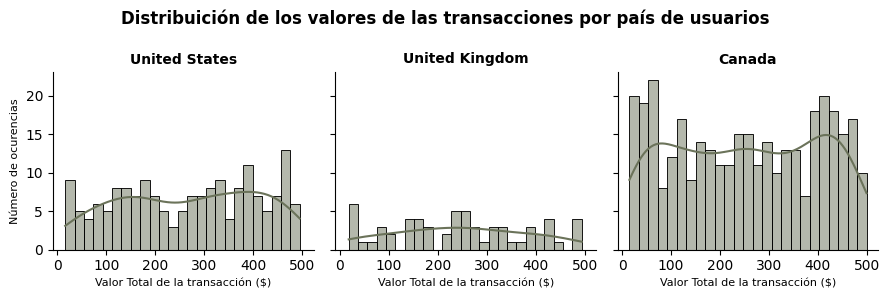

In [58]:
grafico = sns.FacetGrid(data=df_db_transactions.merge(df_db_user, left_on='user_id', right_on='id'), col='country')
grafico.map(sns.histplot, 'amount', bins=25, color='#6B735A', kde=True)
grafico.set_titles('{col_name}', size=10, weight='bold')
grafico.set_axis_labels('Valor Total de la transacción ($)', 'Número de ocurencias', size=8)
grafico.fig.suptitle('Distribuición de los valores de las transacciones por país de usuarios', fontsize=12, fontweight='bold')
grafico.tight_layout()
plt.show()

Análisis de los resultados: el gráfico muestra la distribución de los valores totales de las transacciones (amount) agrupados por país (country) de los usuarios. Estados Unidos, Reino Unido y Canadá. Cada subgráfico representa un país y se puede observar que: Canadá tiene la mayor variedad de valores en las transacciones, con algunos picos en rangos bajos ($10 a $50) y medios altos ($400 a $450). Reino Unido tiene transacciones que son más predominante bajas y con poca variabilidad, siendo un máximo de 6 ocurrencias en transacciones de montos bajos. Estados Unidos está en medio, con una distribución moderadamente variada y un pico en montos cerca de $500, pudendo identificar algún mercado de producto premium.